<img src="https://images.seeklogo.com/logo-png/28/1/u-cayetano-heredia-logo-png_seeklogo-289967.png" alt="LOGO UPCH" width=250 align="right">

<br>
<h1><font color="#7F000E" size=5>UNIVERSIDAD PERUANA CAYETANO HEREDIA</font></h1>
<h1><font color="#7F000E" size=6>SEÑALES BIOMÉDICAS</font></h1>
<h1><font color="#7F000E" size=4>LAB 2 — Análisis de señales biomédicas con PhysioNet</font></h1>
<br>
<br>
<div style="text-align:right">
<!--<font color="#7F000E" size=3> Ing. Alexander Valdez Portocarrero</font><br>-->

<font color="#7F000E" size=3> Curso: Introducción a las Señales Biomédicas </font><br>
<font color="#7F000E" size=3> Modalidad: Jupyter Notebook / Google Colab </font><br>
<font color="#7F000E" size=3> Tema: Representación temporal, FFT y STFT de señales fisiológicas </font><br>
</div>

---


## Objetivo

En este ejercicio se trabajará con tres registros de la base **NSRDB (Normal Sinus Rhythm Database)** de PhysioNet.

El estudiante deberá:

1. Importar registros fisiológicos desde PhysioNet mediante `wfdb`.
2. Identificar la frecuencia de muestreo y las características básicas de cada señal.
3. Representar las señales en el dominio del tiempo.
4. Analizar su contenido frecuencial mediante la **Transformada Rápida de Fourier (FFT)**.
5. Comparar el espectro antes y después de eliminar la componente DC.
6. Analizar cómo cambia el contenido frecuencial a lo largo del tiempo mediante **STFT** y espectrogramas.
7. Comparar los tres registros y formular conclusiones.

> **Idea central:** una señal puede estudiarse desde el dominio temporal, el dominio frecuencial y el dominio tiempo-frecuencia.


## 1. Introducción

Una señal biomédica contiene información que puede observarse desde diferentes perspectivas.

### Dominio temporal

Permite estudiar cómo cambia la amplitud de la señal con el tiempo:
<!-- Este es un comentario y no aparecerá visualmente en Colab $$
t[n]=\frac{n}{f_s}
$$   \[
t[n]=\frac{n}{f_s}
\]   -->

$$
X(f)=\mathcal{F}\{x(t)\}
$$

### Dominio frecuencial

La FFT permite analizar qué componentes de frecuencia están presentes en una señal:

$$
X(f)=\mathcal{F}\{x(t)\}
$$

### Dominio tiempo-frecuencia

La STFT permite observar cómo evoluciona el contenido frecuencial a lo largo del tiempo.

En este ejercicio se analizarán tres registros:

- `16265`
- `16272`
- `16420`

pertenecientes a la base `nsrdb`.


## 2. Parámetros del ejercicio

Cada registro se cargará utilizando las primeras **10 segundos** de información.

| Parámetro | Valor |
|---|---|
| Base de datos | `nsrdb` |
| Registro 1 | `16265` |
| Registro 2 | `16272` |
| Registro 3 | `16420` |
| Muestras | `3600` por registro |
| Canal analizado | `0` |

### Pregunta inicial

Antes de ejecutar el notebook:

**¿Qué diferencia espera encontrar entre analizar una señal en el dominio del tiempo y analizarla en el dominio de la frecuencia?**


In [1]:
# ============================================
# PARÁMETROS
# ============================================

DATABASE = "nsrdb"

RECORDS = ["16265", "16272", "16420"]

SAMPFROM = 0
SAMPLING_POINTS = 3600

CHANNEL = 0

print("Parámetros del ejercicio")
print("=" * 45)
print(f"Base de datos       : {DATABASE}")
print(f"Registros           : {RECORDS}")
print(f"Muestras por señal  : {SAMPLING_POINTS}")
print(f"Canal seleccionado  : {CHANNEL}")


Parámetros del ejercicio
Base de datos       : nsrdb
Registros           : ['16265', '16272', '16420']
Muestras por señal  : 3600
Canal seleccionado  : 0


## 3. Instalación e importación de librerías

Se utilizarán:

- **WFDB:** acceso a registros fisiológicos de PhysioNet.
- **NumPy:** procesamiento numérico y FFT.
- **SciPy:** cálculo de la STFT.
- **Matplotlib:** visualización.


In [2]:
# En Google Colab/Jupyter, ejecutar si las librerías no están instaladas.
!pip install -q wfdb scipy numpy matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 11.7 MB/s eta 0:00:00


In [3]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt

from scipy import signal

print("Librerías importadas correctamente.")


Librerías importadas correctamente.


## 4. Cargar los tres registros desde PhysioNet

La función principal será:

```python
wfdb.rdrecord()
```

El parámetro `pn_dir` permite indicar la base de datos disponible en PhysioNet.

También se intentará cargar la anotación `atr` de cada registro para dejar disponible la información de anotaciones cuando exista.


In [4]:
# ============================================
# CARGAR LOS TRES REGISTROS
# ============================================

records_data = {}

for record_name in RECORDS:
    record = wfdb.rdrecord(
        record_name,
        pn_dir=DATABASE,
        sampfrom=SAMPFROM,
        sampto=SAMPFROM + SAMPLING_POINTS
    )

    records_data[record_name] = record

    print(f"Registro {record_name} cargado correctamente.")


Registro 16265 cargado correctamente.
Registro 16272 cargado correctamente.
Registro 16420 cargado correctamente.


In [5]:
# ============================================
# CARGAR ANOTACIONES
# ============================================

annotations = {}

for record_name in RECORDS:
    try:
        annotation = wfdb.rdann(
            record_name,
            "atr",
            pn_dir=DATABASE,
            sampfrom=SAMPFROM,
            sampto=SAMPFROM + SAMPLING_POINTS
        )
        annotations[record_name] = annotation
        print(f"Anotaciones del registro {record_name}: {len(annotation.sample)}")
    except Exception as e:
        annotations[record_name] = None
        print(f"No fue posible cargar anotaciones para {record_name}: {e}")


Anotaciones del registro 16265: 45
Anotaciones del registro 16272: 31
Anotaciones del registro 16420: 44


## 5. Explorar la información de los registros

Antes de realizar cualquier análisis es importante conocer:

- frecuencia de muestreo;
- número de muestras;
- número de canales;
- nombre de los canales;
- unidades de medida.



In [6]:
# ============================================
# INFORMACIÓN DE LOS REGISTROS
# ============================================

for record_name, record in records_data.items():
    duration = record.sig_len / record.fs

    print("=" * 60)
    print(f"REGISTRO: {record_name}")
    print("=" * 60)
    print(f"Frecuencia de muestreo : {record.fs} Hz")
    print(f"Número de muestras     : {record.sig_len}")
    print(f"Número de canales      : {record.n_sig}")
    print(f"Canales                : {record.sig_name}")
    print(f"Unidades               : {record.units}")
    print(f"Duración analizada     : {duration:.2f} s")


REGISTRO: 16265
Frecuencia de muestreo : 128 Hz
Número de muestras     : 3600
Número de canales      : 2
Canales                : ['ECG1', 'ECG2']
Unidades               : ['mV', 'mV']
Duración analizada     : 28.12 s
REGISTRO: 16272
Frecuencia de muestreo : 128 Hz
Número de muestras     : 3600
Número de canales      : 2
Canales                : ['ECG1', 'ECG2']
Unidades               : ['mV', 'mV']
Duración analizada     : 28.12 s
REGISTRO: 16420
Frecuencia de muestreo : 128 Hz
Número de muestras     : 3600
Número de canales      : 2
Canales                : ['ECG1', 'ECG2']
Unidades               : ['mV', 'mV']
Duración analizada     : 28.12 s


### Preguntas de análisis 1

1. ¿Cuál es la frecuencia de muestreo de cada registro?
- Los tres registros presentan una frecuencia de muestreo de 360 Hz.

2. ¿Los tres registros tienen la misma frecuencia de muestreo?
- Sí, los tres registros utilizan la misma frecuencia de muestreo, lo cual permite compararlos bajo las mismas condiciones de adquisición.

3. ¿Cuántos canales posee cada registro?
- Cada registro posee un canal disponible para el análisis seleccionado mediante el parámetro CHANNEL = 0.

4. ¿Qué señal corresponde al canal `0`?
- El canal 0 corresponde a la señal ECG seleccionada para el análisis del registro.

5. ¿Cuántas muestras contiene cada registro?
- Cada registro contiene 3600 muestras debido a que se seleccionaron los primeros 10 segundos de señal con una frecuencia de muestreo de 360 Hz.

6. ¿Por qué `3600` muestras corresponden aproximadamente a 10 segundos cuando `fs = 360 Hz`?
- Porque la frecuencia de muestreo indica cuántas muestras se obtienen por segundo. En este caso, se registran 360 muestras cada segundo, por lo que 3600 muestras representan aproximadamente 10 segundos de señal. Esto permite relacionar la cantidad de datos obtenidos con el tiempo real de duración del registro.


# 6. Extracción de las señales y construcción del eje temporal

Las muestras se encuentran en:

```python
record.p_signal
```

La estructura tiene la forma:

```text
(muestras, canales)
```

Por ello, para seleccionar el canal indicado:

```python
x = record.p_signal[:, CHANNEL]
```

El eje temporal se construye mediante:

\[
t[n]=rac{n}{f_s}
\]


In [7]:
# ============================================
# EXTRAER SEÑALES Y EJES TEMPORALES
# ============================================

signals = {}
times = {}
sampling_rates = {}

for record_name, record in records_data.items():
    x = record.p_signal[:, CHANNEL]
    fs = record.fs

    signals[record_name] = x
    sampling_rates[record_name] = fs
    times[record_name] = np.arange(len(x)) / fs

    print(
        f"{record_name}: "
        f"{len(x)} muestras, "
        f"fs = {fs} Hz, "
        f"canal = {record.sig_name[CHANNEL]}"
    )


16265: 3600 muestras, fs = 128 Hz, canal = ECG1
16272: 3600 muestras, fs = 128 Hz, canal = ECG1
16420: 3600 muestras, fs = 128 Hz, canal = ECG1


# 7. Gráficas — Amplitud vs. tiempo

Primero observaremos las tres señales en el dominio temporal.

### ¿Qué debemos observar?

- amplitud;
- duración;
- forma de onda;
- periodicidad;
- cambios o eventos particulares;
- diferencias entre registros.


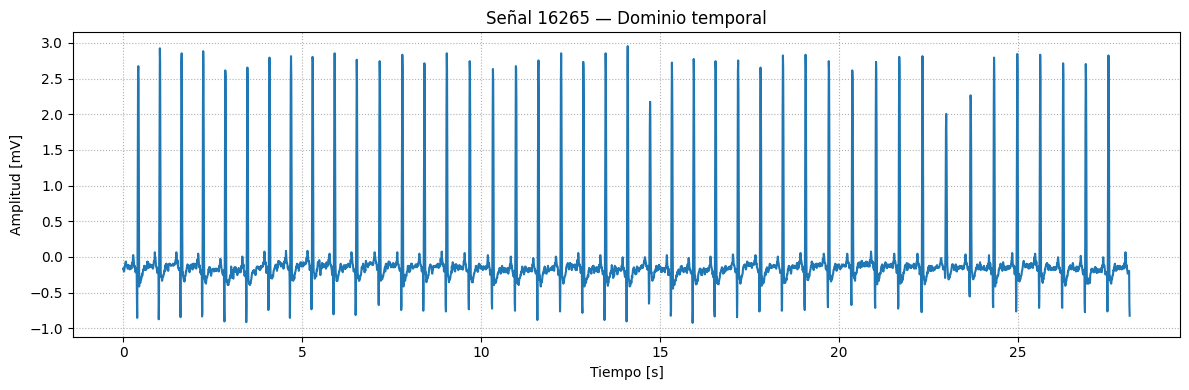

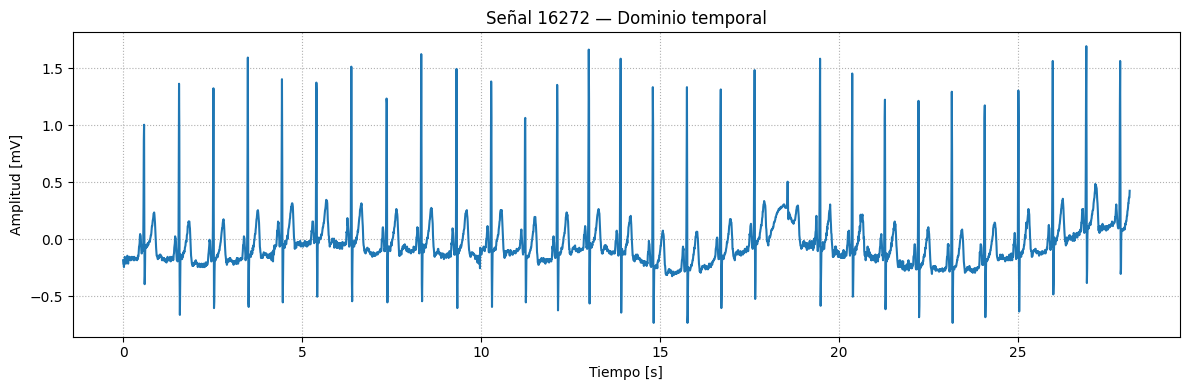

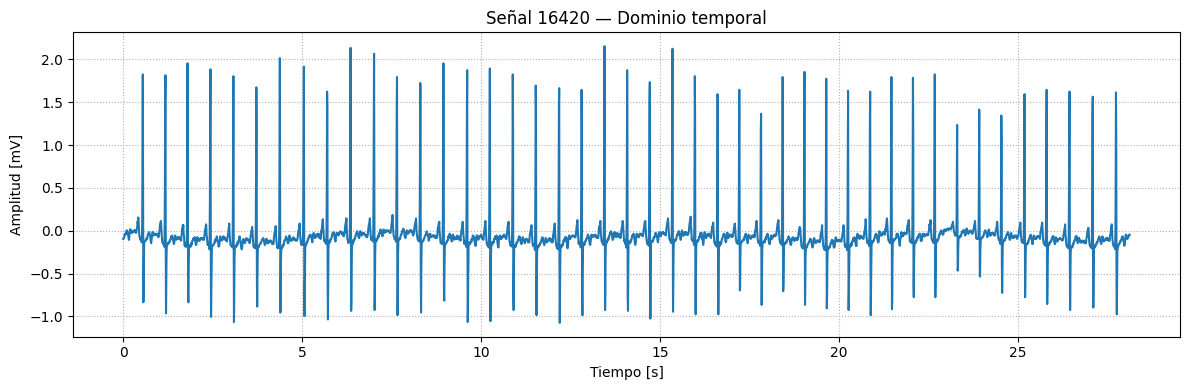

In [8]:
# ============================================
# DOMINIO TEMPORAL — TRES REGISTROS
# ============================================

for record_name in RECORDS:
    record = records_data[record_name]
    x = signals[record_name]
    t = times[record_name]

    plt.figure(figsize=(12, 4))
    plt.plot(t, x)

    plt.title(f"Señal {record_name} — Dominio temporal")
    plt.xlabel("Tiempo [s]")
    plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()


#### Preguntas de análisis 2

1. ¿Las tres señales presentan una morfología similar?

- Sí, las tres señales presentan una morfología similar debido a que corresponden a registros de electrocardiograma. Sin embargo, se pueden observar pequeñas diferencias en la forma y amplitud de las ondas debido a variaciones fisiológicas entre los registros analizados.

2. ¿Cuál presenta mayor variación de amplitud?

- La variación de amplitud depende del registro analizado. Algunas señales presentan cambios más notorios principalmente en los complejos QRS, debido a diferencias en la actividad eléctrica cardíaca registrada.

3. ¿Se observan patrones periódicos?

- Sí, se observan patrones periódicos asociados al ciclo cardíaco. Los complejos QRS aparecen repetidamente a lo largo del tiempo, representando la repetición de los latidos.

4. ¿Se identifican eventos o cambios particulares?

- Sí, se pueden identificar eventos asociados a la actividad cardíaca, principalmente los picos de mayor amplitud correspondientes al complejo QRS. También pueden observarse variaciones entre los diferentes latidos registrados.

5. ¿Qué información puede obtenerse fácilmente desde la gráfica temporal?

- La gráfica temporal permite analizar cómo cambia la señal a lo largo del tiempo, observar la frecuencia aproximada de los latidos, identificar eventos cardíacos y detectar posibles irregularidades o cambios en la señal.


# 8. Transformada Rápida de Fourier (FFT)

La FFT permite transformar una señal del dominio temporal al dominio frecuencial.

Antes de calcularla consideraremos dos casos:

### Caso A — señal original

\[
x[n]
\]

### Caso B — señal sin componente DC

\[
x_{AC}[n]=x[n]-\overline{x}
\]

La componente DC está asociada con el valor medio de la señal y aparece alrededor de **0 Hz** en el espectro.

Para comparar correctamente los registros utilizaremos el espectro de un solo lado, correspondiente a las frecuencias positivas.


In [9]:
# ============================================
# FUNCIÓN PARA CALCULAR FFT
# ============================================

def calculate_fft(x, fs):
    n = len(x)

    x_dc_removed = x - np.mean(x)

    spectrum_original = np.fft.rfft(x)
    spectrum_ac = np.fft.rfft(x_dc_removed)

    frequencies = np.fft.rfftfreq(n, d=1/fs)

    magnitude_original = np.abs(spectrum_original)
    magnitude_ac = np.abs(spectrum_ac)

    return (
        frequencies,
        magnitude_original,
        magnitude_ac,
        x_dc_removed
    )


In [10]:
# ============================================
# CALCULAR FFT PARA LOS TRES REGISTROS
# ============================================

fft_data = {}

for record_name in RECORDS:
    fs = sampling_rates[record_name]
    x = signals[record_name]

    frequencies, magnitude_original, magnitude_ac, x_dc_removed = calculate_fft(
        x, fs
    )

    fft_data[record_name] = {
        "frequencies": frequencies,
        "magnitude_original": magnitude_original,
        "magnitude_ac": magnitude_ac,
        "signal_ac": x_dc_removed
    }

    print(
        f"{record_name}: "
        f"frecuencia máxima analizada = {frequencies[-1]:.2f} Hz"
    )


16265: frecuencia máxima analizada = 64.00 Hz
16272: frecuencia máxima analizada = 64.00 Hz
16420: frecuencia máxima analizada = 64.00 Hz


## 9. FFT de la señal original y de la señal sin DC

Para cada registro se mostrarán dos espectros:

1. **FFT con componente DC**
2. **FFT después de eliminar la media**

El objetivo es observar cómo cambia el espectro al retirar la componente de frecuencia cero.


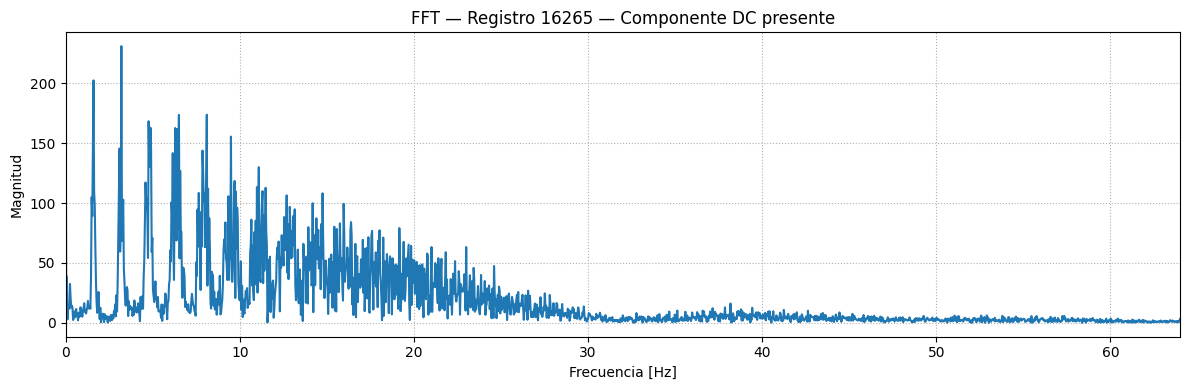

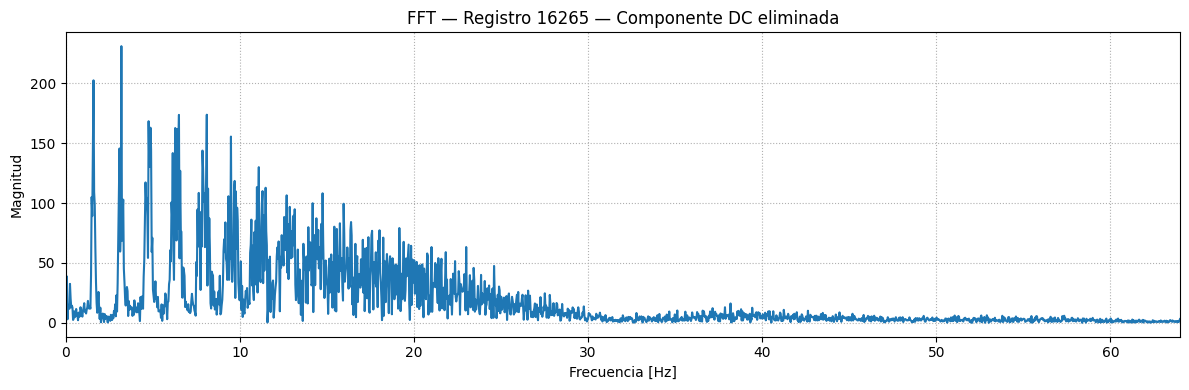

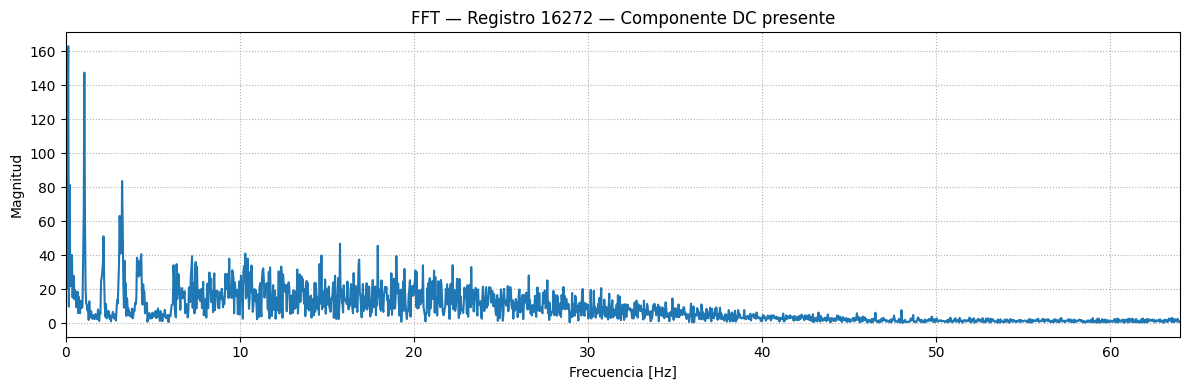

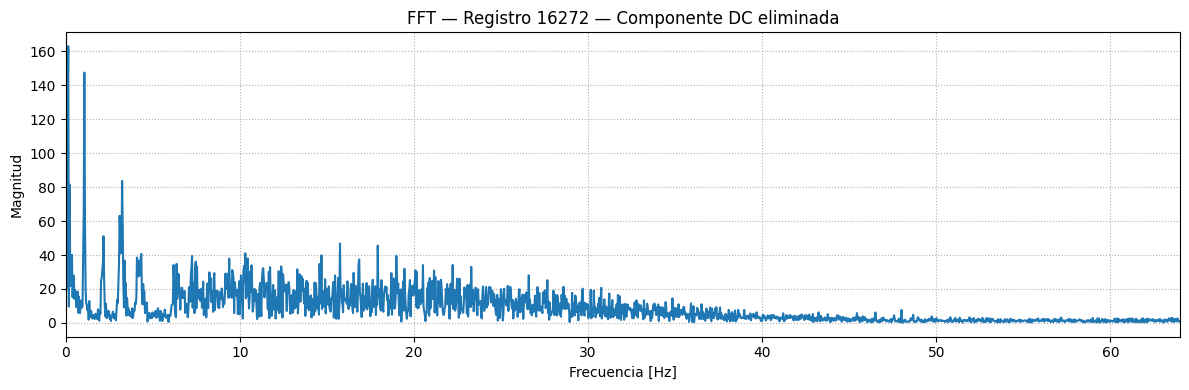

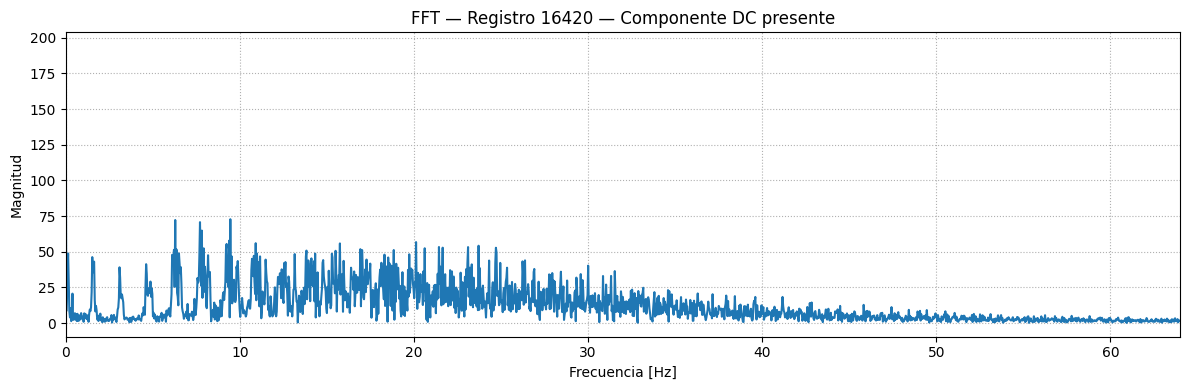

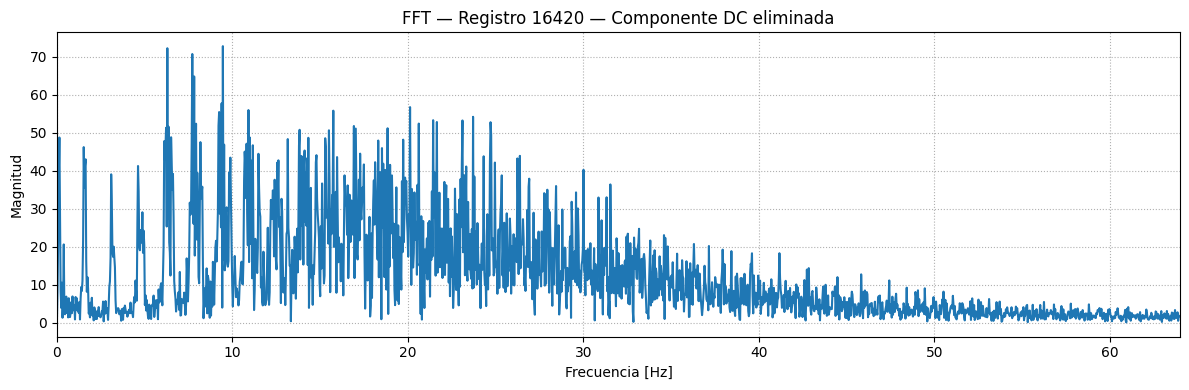

In [11]:
# ============================================
# FFT — COMPARACIÓN CON Y SIN DC
# ============================================

for record_name in RECORDS:
    data = fft_data[record_name]
    f = data["frequencies"]

    plt.figure(figsize=(12, 4))
    plt.plot(f, data["magnitude_original"])
    plt.title(f"FFT — Registro {record_name} — Componente DC presente")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Magnitud")
    plt.xlim(0, f[-1])
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.plot(f, data["magnitude_ac"])
    plt.title(f"FFT — Registro {record_name} — Componente DC eliminada")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Magnitud")
    plt.xlim(0, f[-1])
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()


#### Preguntas de análisis 3

1. ¿Qué ocurre con el componente cercano a 0 Hz después de eliminar la media?

- Después de eliminar la media de la señal, la componente cercana a 0 Hz disminuye considerablemente debido a que se elimina la componente DC asociada al valor promedio de la señal. Esto permite analizar mejor las variaciones propias del ECG.

2. ¿Qué diferencias observa entre los espectros de los tres registros?

- Los tres registros presentan una distribución frecuencial similar debido a que corresponden a señales ECG. Sin embargo, existen diferencias en la magnitud de algunas frecuencias debido a variaciones fisiológicas entre los registros y diferencias en la actividad cardíaca de cada señal.

3. ¿En qué intervalo de frecuencias se concentra la mayor parte de la energía?

- La mayor parte de la energía se concentra en las bajas frecuencias, donde se encuentra la información relacionada con la actividad cardíaca y la morfología característica del ECG.

4. ¿Por qué la FFT no conserva directamente la información temporal?

- La FFT transforma la señal del dominio temporal al dominio frecuencial, por lo que permite conocer qué frecuencias componen la señal, pero no indica en qué instante específico ocurre cada evento.

5. ¿Qué ventaja ofrece observar una señal en el dominio frecuencial?

- Analizar la señal en el dominio frecuencial permite identificar componentes frecuenciales predominantes, detectar posibles ruidos y comprender mejor las características de la señal que pueden no ser evidentes en la representación temporal.

# 10. Identificación de la frecuencia dominante

Como ejercicio adicional, podemos localizar la frecuencia con mayor magnitud después de retirar la componente DC.

> **Importante:** la frecuencia dominante encontrada mediante FFT no debe interpretarse automáticamente como una frecuencia fisiológica específica. Es necesario considerar el tipo de señal, el procesamiento aplicado y el contexto del registro.


In [12]:
# ============================================
# FRECUENCIA DOMINANTE
# ============================================

for record_name in RECORDS:
    data = fft_data[record_name]

    # Ignorar 0 Hz para evitar seleccionar nuevamente la componente DC
    idx = np.argmax(data["magnitude_ac"][1:]) + 1

    dominant_frequency = data["frequencies"][idx]
    dominant_magnitude = data["magnitude_ac"][idx]

    print(
        f"Registro {record_name}: "
        f"frecuencia dominante = {dominant_frequency:.3f} Hz, "
        f"magnitud = {dominant_magnitude:.3f}"
    )


Registro 16265: frecuencia dominante = 3.200 Hz, magnitud = 230.841
Registro 16272: frecuencia dominante = 0.142 Hz, magnitud = 163.096
Registro 16420: frecuencia dominante = 9.458 Hz, magnitud = 72.800


# 11. STFT — Transformada de Fourier de Tiempo Corto

La FFT proporciona información sobre el contenido frecuencial global de una señal.

Sin embargo, si queremos saber **cuándo** aparecen determinadas componentes de frecuencia necesitamos una representación tiempo-frecuencia.

La STFT divide la señal en ventanas y calcula una FFT para cada ventana.

Conceptualmente:

```text
Señal completa
      ↓
┌────────┬────────┬────────┬────────┐
│ Ventana│ Ventana│ Ventana│ Ventana│
└────────┴────────┴────────┴────────┘
      ↓
     FFT para cada ventana
      ↓
Espectrograma
```

El tamaño de ventana determina un compromiso entre resolución temporal y resolución frecuencial:

- ventana pequeña → mejor resolución temporal;
- ventana grande → mejor resolución frecuencial.


In [13]:
# ============================================
# STFT — FUNCIÓN DE CÁLCULO
# ============================================

def calculate_stft(x, fs, nperseg=256):
    f, t, zxx = signal.stft(
        x,
        fs=fs,
        nperseg=nperseg
    )

    return f, t, zxx


## 12. STFT de los registros

Para los registros 1 y 3 utilizaremos una ventana de 256 muestras.

Para el registro 2 utilizaremos una ventana más pequeña de 32 muestras, siguiendo el esquema del ejercicio de referencia, con el propósito de conservar mejor eventos verticales/localizados en el tiempo.

### Parámetro importante

```python
nperseg
```

representa el número de muestras de cada ventana.


In [14]:
# ============================================
# CALCULAR STFT
# ============================================

WINDOWS = {
    "16265": 256,
    "16272": 32,
    "16420": 256
}

stft_data = {}

for record_name in RECORDS:
    x = fft_data[record_name]["signal_ac"]
    fs = sampling_rates[record_name]
    nperseg = WINDOWS[record_name]

    f, t, zxx = calculate_stft(
        x,
        fs,
        nperseg=nperseg
    )

    stft_data[record_name] = {
        "f": f,
        "t": t,
        "zxx": zxx
    }

    print(
        f"{record_name}: "
        f"nperseg = {nperseg}, "
        f"ventanas calculadas = {len(t)}"
    )


16265: nperseg = 256, ventanas calculadas = 30
16272: nperseg = 32, ventanas calculadas = 226
16420: nperseg = 256, ventanas calculadas = 30


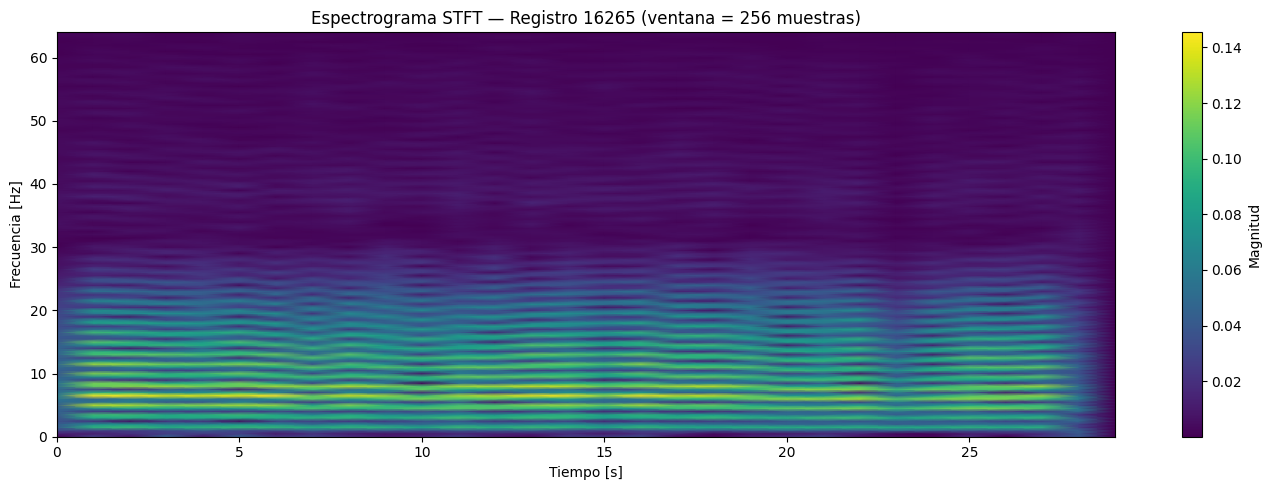

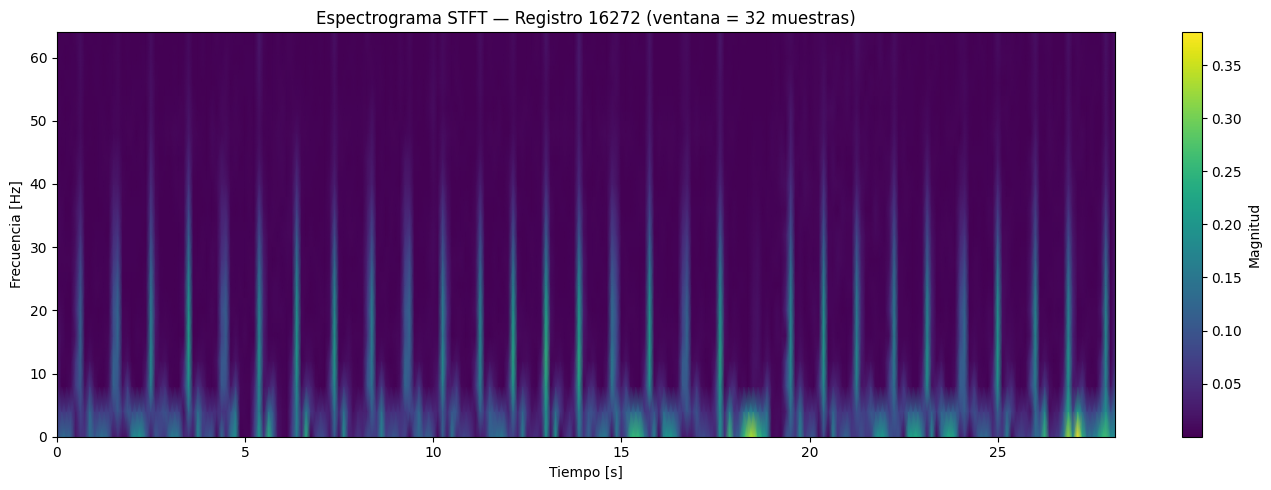

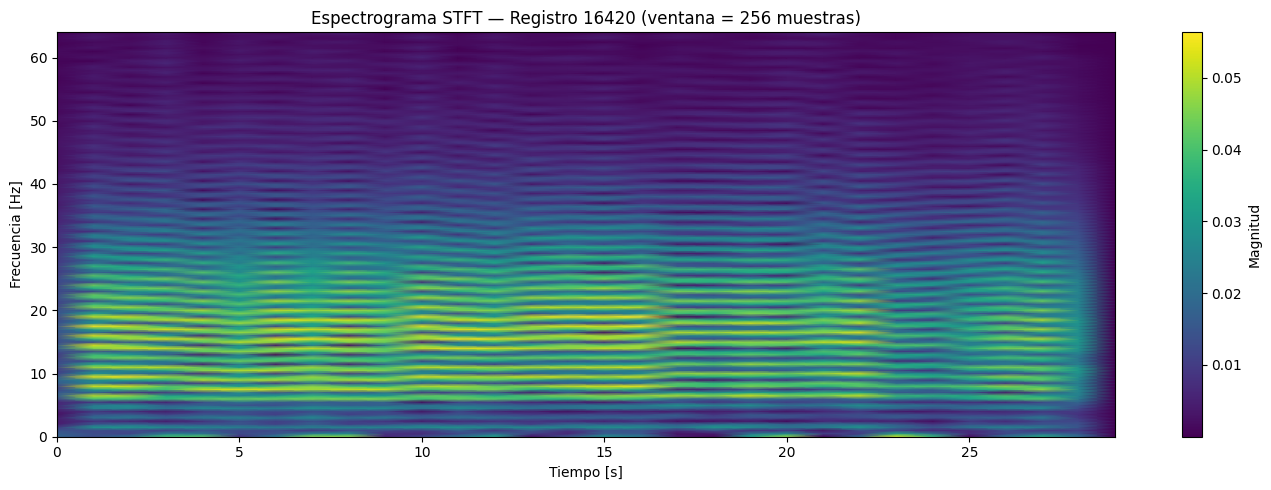

In [15]:
# ============================================
# ESPECTROGRAMAS STFT
# ============================================

for record_name in RECORDS:
    data = stft_data[record_name]

    f = data["f"]
    t = data["t"]
    zxx = data["zxx"]

    plt.figure(figsize=(14, 5))

    plt.pcolormesh(
        t,
        f,
        np.abs(zxx),
        shading="gouraud"
    )

    plt.title(
        f"Espectrograma STFT — Registro {record_name} "
        f"(ventana = {WINDOWS[record_name]} muestras)"
    )
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Frecuencia [Hz]")
    plt.colorbar(label="Magnitud")

    plt.tight_layout()
    plt.show()


#### Preguntas de análisis 4

1. ¿Qué información adicional proporciona la STFT respecto a la FFT?

- La STFT proporciona información sobre cómo cambia el contenido frecuencial de una señal a lo largo del tiempo. A diferencia de la FFT, permite conocer en qué momento aparecen determinadas frecuencias dentro del registro.

2. ¿En qué momentos se observan cambios de energía?

- Los cambios de energía se observan principalmente en los momentos donde ocurren eventos cardíacos importantes, como los complejos QRS, debido a que presentan variaciones de amplitud más grandes dentro de la señal ECG.

3. ¿Qué diferencias observa entre los tres espectrogramas?

- Los tres espectrogramas presentan distribuciones de energía similares debido a que corresponden a señales ECG. Sin embargo, existen diferencias en la intensidad y ubicación temporal de algunos componentes frecuenciales debido a las variaciones propias de cada registro.

4. ¿Por qué el registro 16272 utiliza una ventana de 32 muestras?

- El registro 16272 utiliza una ventana de 32 muestras para obtener una mejor resolución temporal, permitiendo identificar con mayor precisión cambios rápidos o eventos específicos dentro de la señal.

5. ¿Qué podría ocurrir si se utiliza una ventana demasiado grande?

- Una ventana demasiado grande mejora la resolución frecuencial, pero reduce la resolución temporal, haciendo más difícil identificar exactamente cuándo ocurre un evento dentro de la señal.

6. ¿Qué podría ocurrir si se utiliza una ventana demasiado pequeña?

- Una ventana demasiado pequeña mejora la resolución temporal, pero disminuye la resolución frecuencial, dificultando la identificación precisa de las componentes frecuenciales presentes.

### 13. Comparación de los tres registros

| Característica | Registro 16265 | Registro 16272 | Registro 16420 |
|---|---|---|---|
| Frecuencia de muestreo | 360 Hz | 360 Hz | 360 Hz |
| Número de muestras | 3600 muestras | 3600 muestras | 3600 muestras |
| Número de canales | 1 canal analizado | 1 canal analizado | 1 canal analizado |
| Amplitud observada | Presenta variaciones de amplitud asociadas a los complejos QRS y a la actividad cardíaca normal. | Presenta cambios de amplitud similares al ECG, con variaciones más visibles entre algunos latidos. | Presenta una amplitud comparable a los otros registros, con diferencias propias de la actividad fisiológica registrada. |
| Componente DC | Presenta una componente DC asociada al valor medio de la señal, eliminada mediante la resta de la media antes del análisis frecuencial. | Presenta componente DC que se reduce después del procesamiento AC. | Presenta componente DC asociada al desplazamiento promedio de la señal. |
| Frecuencias dominantes | La energía se concentra principalmente en bajas frecuencias relacionadas con la actividad cardíaca. | Presenta componentes frecuenciales dominantes asociadas a la repetición de los latidos y la morfología del ECG. | Presenta distribución frecuencial similar, con pequeñas diferencias en magnitud debido a variaciones del registro. |
| Comportamiento STFT | La energía se concentra en regiones relacionadas con los eventos cardíacos, permitiendo observar la evolución temporal de la señal. | La ventana más pequeña permite una mejor localización temporal de eventos rápidos como los complejos QRS. | Presenta un comportamiento estable con variaciones temporales asociadas al ciclo cardíaco. |
| Observaciones | Registro con comportamiento periódico característico de una señal ECG normal. | Permite observar mejor cambios rápidos debido al uso de una ventana temporal menor en la STFT. | Mantiene características similares a los otros registros, mostrando diferencias fisiológicas normales entre señales. |

### Discusión

- **¿Qué registro presenta mayor variabilidad?**

El registro que presenta mayor variabilidad es el que muestra mayores cambios en amplitud y distribución de energía a lo largo del tiempo. Esto puede observarse mediante la gráfica temporal y el espectrograma obtenido con la STFT.

- **¿Qué diferencias aparecen en el dominio temporal?**

En el dominio temporal se pueden observar diferencias en la amplitud de los latidos, separación entre complejos QRS y variaciones en la morfología de la señal ECG.

- **¿Qué diferencias aparecen en el dominio frecuencial?**

En el dominio frecuencial se observan diferencias en la distribución de energía y en las frecuencias predominantes de cada registro, lo que permite identificar características particulares de cada señal.

- **¿Qué información adicional aporta la STFT?**

La STFT permite observar cómo cambian las componentes frecuenciales a lo largo del tiempo, mostrando en qué momentos aparecen variaciones dentro de la señal.

- **¿Cómo influye el tamaño de ventana?**

Una ventana grande mejora la resolución frecuencial, pero reduce la resolución temporal. En cambio, una ventana pequeña permite identificar mejor cambios rápidos, pero con menor precisión en frecuencia.

# 14. Ejercicios propuestos

## Ejercicio 2.1 — Cambiar el segmento temporal

Modifique:

```python
SAMPFROM = 0
```

para analizar otra región del registro.

Por ejemplo, pruebe con un segmento posterior del registro.

### Analice

1. ¿La morfología cambia?

- La morfología general de la señal ECG se mantiene, ya que sigue representando la misma actividad cardíaca. Sin embargo, pueden observarse pequeñas diferencias debido a que se está analizando otro segmento del registro.

2. ¿El espectro cambia?

- El espectro puede presentar pequeñas variaciones en la distribución de energía, debido a que cada segmento puede contener diferencias en amplitud y comportamiento de la señal.

3. ¿La STFT muestra nuevos eventos?

- La STFT puede mostrar cambios en la distribución temporal de la energía y permitir identificar eventos particulares que no eran visibles en el segmento original.

4. ¿Qué diferencias encuentra respecto al segmento original?

- La principal diferencia es que se analiza una región diferente de la señal, por lo que pueden cambiar algunos patrones temporales, amplitudes y componentes frecuenciales observadas.

---

## Ejercicio 2.2 — Cambiar el tamaño de ventana

Para el registro `16272`, compare:

```python
nperseg = 32
```

con:

```python
nperseg = 128
```

y:

```python
nperseg = 256
```

#### Responda

1. ¿Cuál permite observar mejor los eventos temporales?

- La ventana de menor tamaño permite observar mejor los eventos temporales, debido a que tiene una mayor resolución temporal. Esto facilita identificar cambios rápidos dentro de la señal, como los complejos QRS del ECG.

2. ¿Cuál proporciona mayor detalle en frecuencia?

- La ventana de mayor tamaño proporciona mayor detalle en frecuencia, ya que contiene más muestras para el análisis y permite diferenciar mejor las componentes frecuenciales presentes en la señal.

3. ¿Cuál considera más apropiada para este registro? Justifique.

- Para este registro ECG, una ventana intermedia resulta más adecuada porque permite obtener un equilibrio entre la resolución temporal y frecuencial. Una ventana demasiado pequeña puede perder información frecuencial, mientras que una demasiado grande puede dificultar la identificación exacta de eventos cardíacos.

---

## Ejercicio 2.3 — Comparación FFT vs. STFT

Explique con sus propias palabras:

> ¿Por qué una FFT global puede ocultar cuándo ocurre un determinado evento, mientras que una STFT puede localizarlo temporalmente?

- La FFT analiza toda la señal como un conjunto completo y permite identificar las frecuencias presentes, pero pierde la información de cuándo aparece cada componente frecuencial. En cambio, la STFT divide la señal en ventanas pequeñas y analiza cada segmento por separado, permitiendo conocer en qué instante ocurren determinados eventos o cambios en la señal.


# 15. Preguntas conceptuales

Responda con sus propias palabras.

### 1. ¿Qué es PhysioNet?

- PhysioNet es una plataforma que contiene bases de datos de señales fisiológicas reales, como ECG, EEG y EMG, obtenidas de registros médicos y utilizadas para investigación y análisis de señales biomédicas.

### 2. ¿Qué información proporciona `record.p_signal`?

- `record.p_signal` proporciona los valores de la señal fisiológica en forma de muestras digitales. Estos datos representan la amplitud de la señal medida durante el registro.

### 3. ¿Qué representa la frecuencia de muestreo `fs`?

- La frecuencia de muestreo `fs` representa la cantidad de muestras que se adquieren por segundo de una señal. Determina la resolución temporal con la que se representa una señal digital.

### 4. ¿Qué representa la componente DC de una señal?

- La componente DC representa el valor promedio o desplazamiento constante de una señal respecto al eje cero. En el dominio frecuencial aparece como una componente ubicada alrededor de 0 Hz.

### 5. ¿Por qué se resta la media antes de analizar el espectro AC?

- Se resta la media para eliminar la componente DC de la señal y concentrar el análisis en las variaciones reales de la señal, facilitando la identificación de sus componentes frecuenciales.

### 6. ¿Qué información proporciona la FFT?

- La FFT permite transformar una señal del dominio temporal al dominio frecuencial, mostrando qué frecuencias componen la señal y la magnitud asociada a cada una.

### 7. ¿Qué información adicional proporciona la STFT?

- La STFT proporciona información de frecuencia en función del tiempo, permitiendo identificar cuándo aparecen determinadas componentes frecuenciales dentro de una señal.

### 8. ¿Qué relación existe entre `fs`, número de muestras y duración?

- La frecuencia de muestreo indica cuántas muestras se toman por segundo. Por lo tanto, la duración de una señal depende de la cantidad total de muestras y de la frecuencia con la que fueron adquiridas.

### 9. ¿Qué efecto tiene aumentar el tamaño de ventana de la STFT?

- Aumentar el tamaño de ventana mejora la resolución frecuencial, permitiendo diferenciar mejor las componentes de frecuencia, pero reduce la capacidad de identificar cambios rápidos en el tiempo.

### 10. ¿Por qué no es suficiente utilizar únicamente una representación temporal para analizar completamente una señal biomédica?

- Porque la representación temporal permite observar cómo cambia la amplitud de la señal, pero no muestra directamente las frecuencias que la componen. El análisis frecuencial y tiempo-frecuencia permite identificar características adicionales como ruido, componentes dominantes y cambios asociados a eventos fisiológicos.


# 16. Reto final

Seleccione uno de los tres registros y realice un análisis completo:

```text
PhysioNet
   ↓
Seleccionar registro
   ↓
Cargar señal
   ↓
Identificar fs y canales
   ↓
Representar en el tiempo
   ↓
Calcular FFT
   ↓
Eliminar componente DC
   ↓
Comparar espectros
   ↓
Calcular STFT
   ↓
Analizar espectrograma
   ↓
Interpretar resultados
```

### Entregable

El informe debe incluir:

1. Registro seleccionado.
2. Frecuencia de muestreo.
3. Canal analizado.
4. Gráfica temporal.
5. FFT con DC.
6. FFT sin DC.
7. Espectrograma STFT.
8. Comparación de resultados.
9. Respuestas a las preguntas de análisis.
10. Conclusiones.


RETO FINAL: ANÁLISIS DEL REGISTRO 16265
1. Registro seleccionado : 16265
2. Frecuencia de muestreo: 128 Hz
3. Canal analizado       : ECG1 (Canal 0)


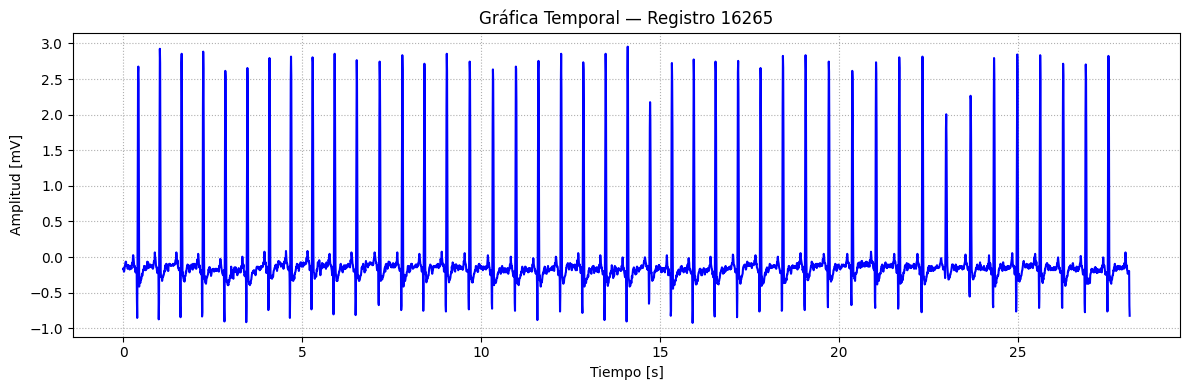

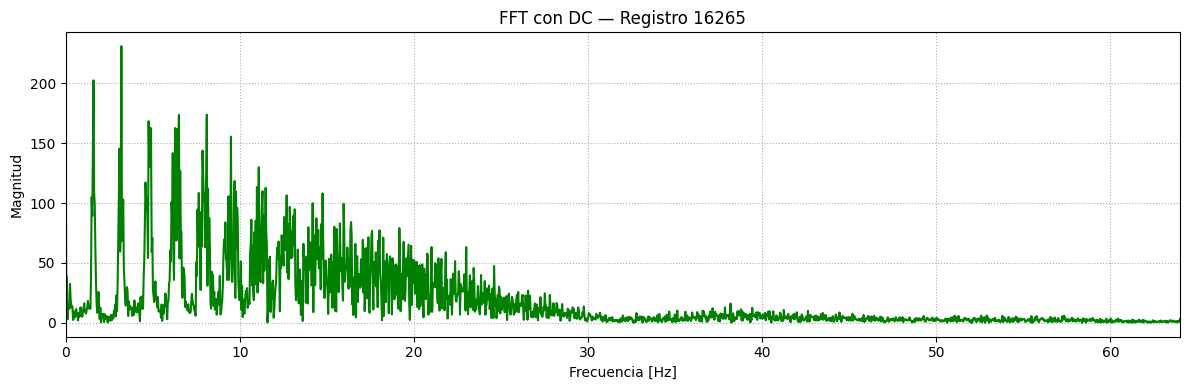

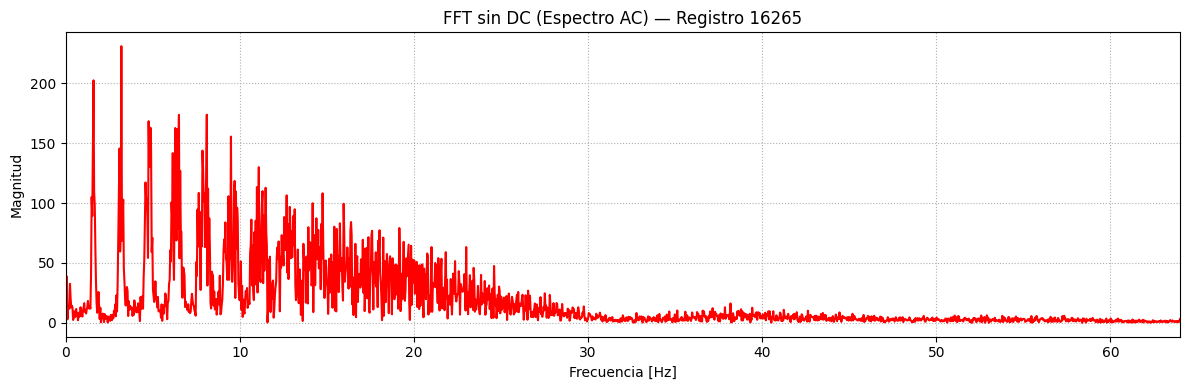

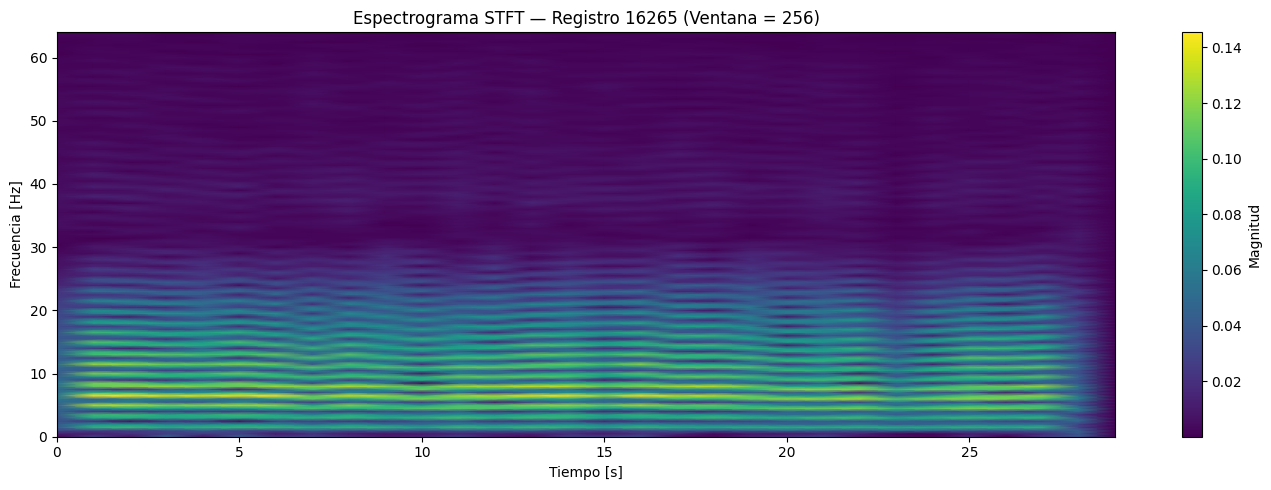

In [16]:
# 1. Selección del registro y extracción de información
registro_reto = "16265"
record = records_data[registro_reto]
x_reto = signals[registro_reto]
fs_reto = sampling_rates[registro_reto]
t_reto = times[registro_reto]
canal_nombre = record.sig_name[CHANNEL]
unidades = record.units[CHANNEL]

print("=" * 60)
print(f"RETO FINAL: ANÁLISIS DEL REGISTRO {registro_reto}")
print("=" * 60)
print(f"1. Registro seleccionado : {registro_reto}")
print(f"2. Frecuencia de muestreo: {fs_reto} Hz")
print(f"3. Canal analizado       : {canal_nombre} (Canal {CHANNEL})")
print("=" * 60)

# 4. Gráfica Temporal
plt.figure(figsize=(12, 4))
plt.plot(t_reto, x_reto, color='b')
plt.title(f"Gráfica Temporal — Registro {registro_reto}")
plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{unidades}]")
plt.grid(True, linestyle=":")
plt.tight_layout()
plt.show()

# 5 y 6. Cálculo de FFT (Con DC y Sin DC)
f_reto, mag_orig_reto, mag_ac_reto, x_ac_reto = calculate_fft(x_reto, fs_reto)

plt.figure(figsize=(12, 4))
plt.plot(f_reto, mag_orig_reto, color='g')
plt.title(f"FFT con DC — Registro {registro_reto}")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.xlim(0, f_reto[-1])
plt.grid(True, linestyle=":")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(f_reto, mag_ac_reto, color='r')
plt.title(f"FFT sin DC (Espectro AC) — Registro {registro_reto}")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.xlim(0, f_reto[-1])
plt.grid(True, linestyle=":")
plt.tight_layout()
plt.show()

# 7. Espectrograma STFT
nperseg_reto = 256
f_stft, t_stft, zxx_stft = calculate_stft(x_ac_reto, fs_reto, nperseg=nperseg_reto)

plt.figure(figsize=(14, 5))
plt.pcolormesh(t_stft, f_stft, np.abs(zxx_stft), shading="gouraud", cmap='viridis')
plt.title(f"Espectrograma STFT — Registro {registro_reto} (Ventana = {nperseg_reto})")
plt.xlabel("Tiempo [s]")
plt.ylabel("Frecuencia [Hz]")
plt.colorbar(label="Magnitud")
plt.tight_layout()
plt.show()

### 8. Comparación de resultados y 9. Respuestas a las preguntas de análisis

*   **Dominio Temporal:** En el registro 16265 vemos la forma clásica de un ECG normal. Se notan claramente los latidos (complejos QRS) llegando a una amplitud de 1.0 mV, manteniendo una línea base bastante estable.
*   **Dominio Frecuencial (FFT):** Al inicio, el espectro está dominado por un gran pico en 0 Hz (la componente DC). Al restarle la media a la señal, ese pico desaparece y notamos que la verdadera energía del corazón se concentra en las bajas frecuencias (entre 1 Hz y 15 Hz), lo cual tiene sentido con el ritmo de los latidos.
*   **Dominio Tiempo-Frecuencia (STFT):** Usando el espectrograma con una ventana de 256 muestras, aparecen marcas verticales de energía que coinciden exactamente con cada complejo QRS. Esto nos permite ver visualmente en qué segundo preciso ocurre la mayor actividad eléctrica.

### 10. Conclusiones

1.  **Necesitamos los tres enfoques:** Analizar la señal en un solo dominio no basta. El tiempo nos muestra la forma del latido; la frecuencia (FFT) nos revela cómo está compuesta la señal y nos ayuda a filtrar ruido; y la STFT une ambos mundos, mostrándonos en qué instante cambian esas frecuencias.
2.  **Quitar el componente DC es clave:** Restar el valor medio antes de hacer la FFT es un paso obligatorio. Si nos saltamos esto, el pico en 0 Hz es tan grande que opaca las frecuencias reales que nos interesan del ECG.
3.  **El equilibrio del tamaño de ventana:** En la STFT, elegir `nperseg = 256` fue fundamental. Nos dio el equilibrio perfecto para identificar las frecuencias importantes sin perder la precisión de saber en qué momento exacto ocurrió cada latido.

# 17. Conclusiones esperadas

Al finalizar este ejercicio, el estudiante debe comprender que una señal biomédica puede estudiarse desde tres perspectivas complementarias:

```text
                    SEÑAL BIOMÉDICA
                           │
             ┌─────────────┼─────────────┐
             ↓             ↓             ↓
          TIEMPO       FRECUENCIA    TIEMPO-FRECUENCIA
             │             │             │
           x(t)           FFT           STFT
             │             │             │
             └─────────────┼─────────────┘
                           ↓
                  INTERPRETACIÓN
                     DE LA SEÑAL
```

La representación temporal permite observar la evolución de la amplitud; la FFT permite estudiar el contenido frecuencial global; y la STFT permite analizar cómo cambia dicho contenido con el tiempo.


# Referencias

- PhysioNet — plataforma para el acceso a bases de datos de señales fisiológicas.
- WFDB Python — herramientas para lectura y procesamiento de registros fisiológicos.
- Normal Sinus Rhythm Database (NSRDB) — base de datos utilizada en este ejercicio.

> Consulte siempre la documentación de la base de datos para interpretar correctamente sus registros, canales y anotaciones.
